# ISIT 2026 — Presentation-optimized figures

Slide-ready versions of the deck's data figures. This notebook runs the **same
computation code** as the paper notebooks (`isit_paper_figures.ipynb`,
`delta_entropy_analysis.ipynb`, `variance_independence_check.ipynb`) and only
changes the **presentation styling**: larger fonts, thicker lines/markers,
higher-contrast palettes, and **vector PDF output** (with a high-DPI PNG fallback).

**Runnable + editable.** Run all cells to regenerate the figures. Tweak the
`PRESENTATION_STYLE` block or any per-figure cell and re-run just that cell.

- Data source: `../Responses/*.csv` (sentence-level log-loss values).
- Output: a **held-out** folder `../isit2026/figures/presentation/` (kept separate
  from the paper figures, which are never touched).
- Each figure is saved as **vector PDF** (primary) + **300-dpi PNG** (fallback).
- 3-panel layouts are kept; text is enlarged for projection.

Figures produced (in `figures/presentation/`):
1. `auc_vs_delta_normalized` — slide 8 (Evidence)
2. `human_detection_heatmap` — slide 9 (Human vs LLM)
3. `epsilon_ball_example` — slide 6 (Theorem 2, reconstructed toy example)
4. `delta_auc_by_length` — backup B4
5. `variance_ratio_by_length` — backup B5

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, norm
from sklearn.metrics import roc_auc_score

import importlib
import analysis_utils
importlib.reload(analysis_utils)
from analysis_utils import extract_info_from_path, compute_roc_values

# Global filter: sentences with 10-40 tokens (same as paper)
MIN_LENGTH = 10
MAX_LENGTH = 40

# ---------------------------------------------------------------------------
# Presentation style: large, high-contrast, vector-friendly.
# Only cosmetics change; all computation matches the paper notebooks.
# ---------------------------------------------------------------------------
PRESENTATION_STYLE = {
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "pdf.fonttype": 42,   # embed editable TrueType (no Type-3) for clean PDF
    "ps.fonttype": 42,
    "font.size": 16,
    "axes.titlesize": 20,
    "axes.titleweight": "bold",
    "axes.labelsize": 19,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 15,
    "legend.title_fontsize": 16,
    "lines.linewidth": 2.5,
    "figure.titlesize": 24,
    "figure.titleweight": "bold",
}
plt.rcParams.update(PRESENTATION_STYLE)

# Held-out output folder: kept separate from the paper figures so nothing
# in the deck's main figures/ directory is ever overwritten.
OUTDIR = "../isit2026/figures/presentation"
os.makedirs(OUTDIR, exist_ok=True)

def save_slide(name):
    """Save the current figure as vector PDF (primary) + high-DPI PNG (fallback).

    transparent=True drops the figure/axes background so the plot blends onto the
    deck's (slightly gray) slide canvas instead of sitting on a hard white box.
    """
    for ext in ("pdf", "png"):
        path = os.path.join(OUTDIR, f"{name}.{ext}")
        plt.savefig(path, dpi=300, bbox_inches="tight", transparent=True)
        print(f"saved {path}")

# Shared constants (same as paper notebooks)
DETECTOR_NAMES = ['Llama-3.1-8B', 'Falcon-7B', 'Phi-2', 'DeepSeek-R1']
AUTHOR_NAMES = ['Llama3.1', 'Falcon', 'Human', 'GPT', 'R1']
DATASET_NAMES = ['Wiki', 'News', 'Abstracts']

In [2]:
# Dataset paths (relative to analysis/) -- identical to the paper notebooks
wiki_paths = [
    ["../Responses/wiki_Llama3.1_clean_none_Meta-Llama-3.1-8B-Instruct.csv",
     "../Responses/wiki_Falcon_clean_none_Meta-Llama-3.1-8B-Instruct.csv",
     "../Responses/wiki_human_text_none_Meta-Llama-3.1-8B-Instruct.csv",
     "../Responses/wiki_gpt_clean_none_Meta-Llama-3.1-8B-Instruct.csv",
     "../Responses/wiki_R1_clean_none_Meta-Llama-3.1-8B-Instruct.csv"],
    ["../Responses/wiki_Llama3.1_clean_none_falcon-7b.csv",
     "../Responses/wiki_Falcon_clean_none_falcon-7b.csv",
     "../Responses/wiki_human_text_none_falcon-7b.csv",
     "../Responses/wiki_gpt_clean_none_falcon-7b.csv",
     "../Responses/wiki_R1_clean_none_falcon-7b.csv"],
    ["../Responses/wiki_Llama3.1_clean_none_phi-2.csv",
     "../Responses/wiki_Falcon_clean_none_phi-2.csv",
     "../Responses/wiki_human_text_none_phi-2.csv",
     "../Responses/wiki_gpt_clean_none_phi-2.csv",
     "../Responses/wiki_R1_clean_none_phi-2.csv"],
    ["../Responses/wiki_Llama3.1_clean_none_DeepSeek-R1-Distill-Qwen-7B.csv",
     "../Responses/wiki_Falcon_clean_none_DeepSeek-R1-Distill-Qwen-7B.csv",
     "../Responses/wiki_human_text_none_DeepSeek-R1-Distill-Qwen-7B.csv",
     "../Responses/wiki_gpt_clean_none_DeepSeek-R1-Distill-Qwen-7B.csv",
     "../Responses/wiki_R1_clean_none_DeepSeek-R1-Distill-Qwen-7B.csv"]
]

news_paths = [
    ["../Responses/news_Llama3.1_clean_none_Meta-Llama-3.1-8B-Instruct.csv",
     "../Responses/news_Falcon_clean_none_Meta-Llama-3.1-8B-Instruct.csv",
     "../Responses/news_human_text_none_Meta-Llama-3.1-8B-Instruct.csv",
     "../Responses/news_gpt_clean_none_Meta-Llama-3.1-8B-Instruct.csv",
     "../Responses/news_R1_clean_none_Meta-Llama-3.1-8B-Instruct.csv"],
    ["../Responses/news_Llama3.1_clean_none_falcon-7b.csv",
     "../Responses/news_Falcon_clean_none_falcon-7b.csv",
     "../Responses/news_human_text_none_falcon-7b.csv",
     "../Responses/news_gpt_clean_none_falcon-7b.csv",
     "../Responses/news_R1_clean_none_falcon-7b.csv"],
    ["../Responses/news_Llama3.1_clean_none_phi-2.csv",
     "../Responses/news_Falcon_clean_none_phi-2.csv",
     "../Responses/news_human_text_none_phi-2.csv",
     "../Responses/news_gpt_clean_none_phi-2.csv",
     "../Responses/news_R1_clean_none_phi-2.csv"],
    ["../Responses/news_Llama3.1_clean_none_DeepSeek-R1-Distill-Qwen-7B.csv",
     "../Responses/news_Falcon_clean_none_DeepSeek-R1-Distill-Qwen-7B.csv",
     "../Responses/news_human_text_none_DeepSeek-R1-Distill-Qwen-7B.csv",
     "../Responses/news_gpt_clean_none_DeepSeek-R1-Distill-Qwen-7B.csv",
     "../Responses/news_R1_clean_none_DeepSeek-R1-Distill-Qwen-7B.csv"]
]

abstracts_paths = [
    ["../Responses/abstracts_Llama3.1_clean_none_Meta-Llama-3.1-8B-Instruct.csv",
     "../Responses/abstracts_Falcon_clean_none_Meta-Llama-3.1-8B-Instruct.csv",
     "../Responses/abstracts_human_text_none_Meta-Llama-3.1-8B-Instruct.csv",
     "../Responses/abstracts_gpt_clean_none_Meta-Llama-3.1-8B-Instruct.csv",
     "../Responses/abstracts_R1_clean_none_Meta-Llama-3.1-8B-Instruct.csv"],
    ["../Responses/abstracts_Llama3.1_clean_none_falcon-7b.csv",
     "../Responses/abstracts_Falcon_clean_none_falcon-7b.csv",
     "../Responses/abstracts_human_text_none_falcon-7b.csv",
     "../Responses/abstracts_gpt_clean_none_falcon-7b.csv",
     "../Responses/abstracts_R1_clean_none_falcon-7b.csv"],
    ["../Responses/abstracts_Llama3.1_clean_none_phi-2.csv",
     "../Responses/abstracts_Falcon_clean_none_phi-2.csv",
     "../Responses/abstracts_human_text_none_phi-2.csv",
     "../Responses/abstracts_gpt_clean_none_phi-2.csv",
     "../Responses/abstracts_R1_clean_none_phi-2.csv"],
    ["../Responses/abstracts_Llama3.1_clean_none_DeepSeek-R1-Distill-Qwen-7B.csv",
     "../Responses/abstracts_Falcon_clean_none_DeepSeek-R1-Distill-Qwen-7B.csv",
     "../Responses/abstracts_human_text_none_DeepSeek-R1-Distill-Qwen-7B.csv",
     "../Responses/abstracts_gpt_clean_none_DeepSeek-R1-Distill-Qwen-7B.csv",
     "../Responses/abstracts_R1_clean_none_DeepSeek-R1-Distill-Qwen-7B.csv"]
]

all_dataset_paths = wiki_paths + news_paths + abstracts_paths

## 1. Normalized AUC vs |Δ|/σ — slide 8 (Evidence)

Computation is identical to `isit_paper_figures.ipynb`; only fonts, marker sizes,
and the output format change.

Total points: 720 | Global Pearson r = 0.99


saved ../isit2026/figures/presentation/auc_vs_delta_normalized.pdf


saved ../isit2026/figures/presentation/auc_vs_delta_normalized.png


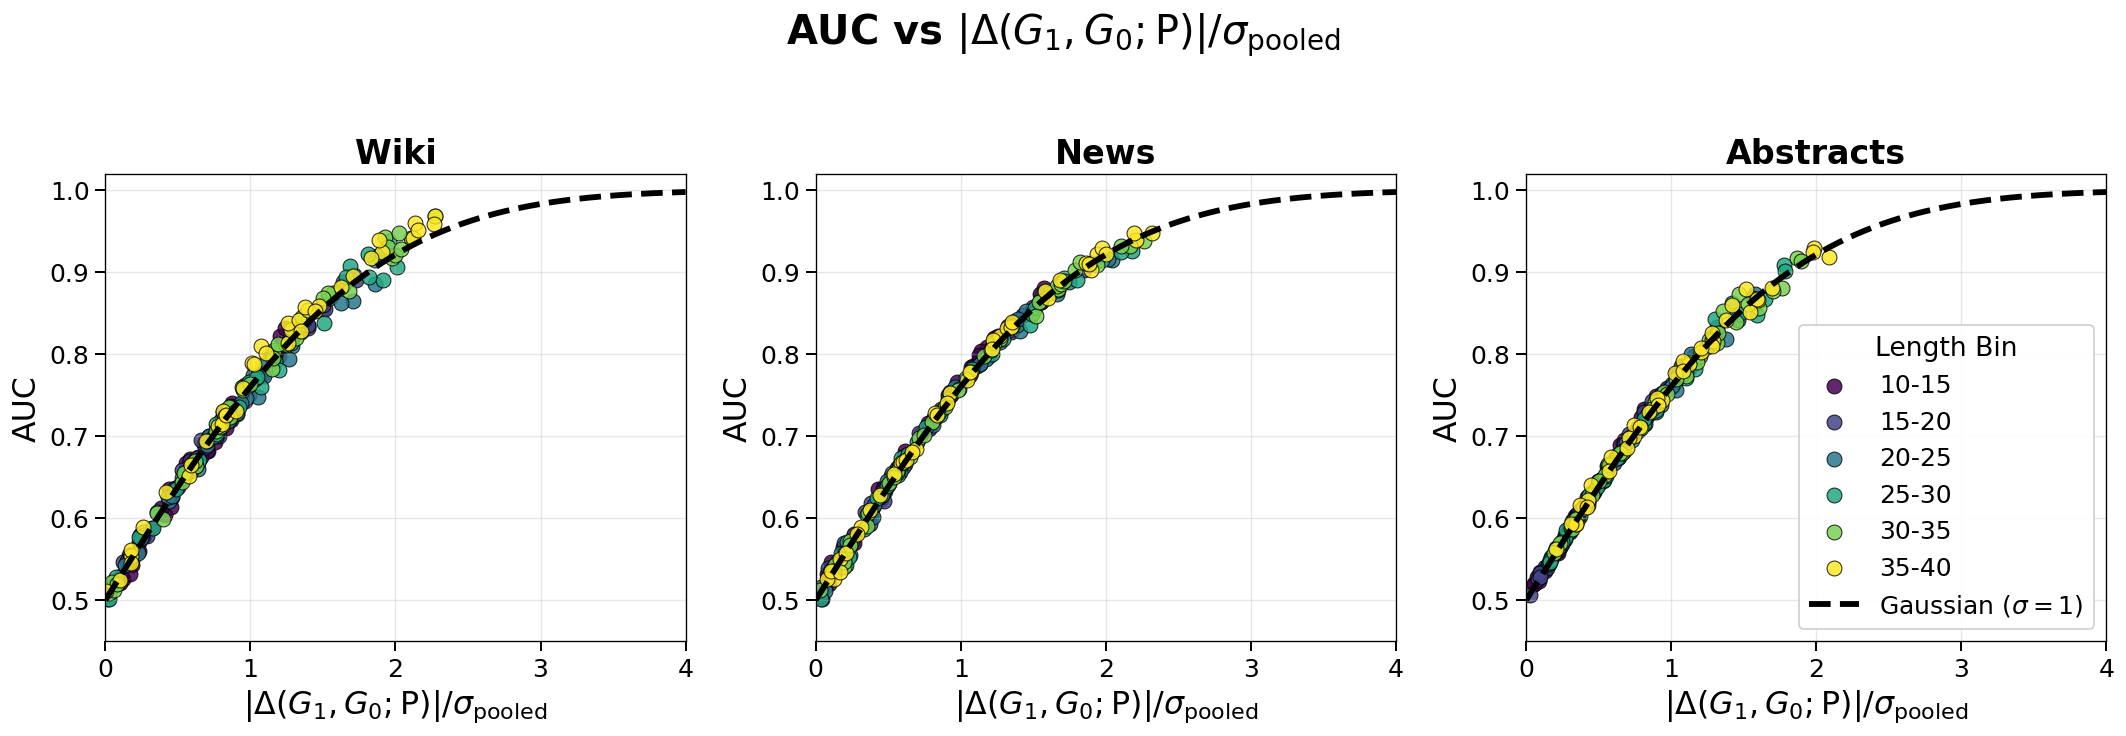

In [3]:
# ---- Computation (verbatim from isit_paper_figures.ipynb) ----
LENGTH_BINS = [(10, 15), (15, 20), (20, 25), (25, 30), (30, 35), (35, 40)]
BIN_LABELS = ['10-15', '15-20', '20-25', '25-30', '30-35', '35-40']
MIN_SAMPLES = 30

def compute_normalized_auc_vs_delta(dataset_paths, dataset_name):
    """Compute |Δ|/σ (normalized delta) and AUC for each comparison."""
    results = []
    for det_idx, lm_paths in enumerate(dataset_paths):
        detector = DETECTOR_NAMES[det_idx]
        for i, auth1_path in enumerate(lm_paths):
            for j, auth2_path in enumerate(lm_paths):
                if i >= j:
                    continue
                auth1_df = pd.read_csv(auth1_path)
                auth2_df = pd.read_csv(auth2_path)
                _, auth1_name, _, _ = extract_info_from_path(auth1_path)
                _, auth2_name, _, _ = extract_info_from_path(auth2_path)
                for bin_idx, (low, high) in enumerate(LENGTH_BINS):
                    mask1 = (auth1_df['length'] >= low) & (auth1_df['length'] < high)
                    mask2 = (auth2_df['length'] >= low) & (auth2_df['length'] < high)
                    subset1 = auth1_df.loc[mask1, 'response'].dropna()
                    subset2 = auth2_df.loc[mask2, 'response'].dropna()
                    if len(subset1) < MIN_SAMPLES or len(subset2) < MIN_SAMPLES:
                        continue
                    mu_0, mu_1 = subset1.mean(), subset2.mean()
                    delta = abs(mu_1 - mu_0)
                    n0, n1 = len(subset1), len(subset2)
                    var0, var1 = subset1.var(), subset2.var()
                    pooled_var = ((n0 - 1) * var0 + (n1 - 1) * var1) / (n0 + n1 - 2)
                    pooled_std = np.sqrt(pooled_var)
                    delta_normalized = delta / pooled_std if pooled_std > 0 else 0
                    y_true = np.concatenate([np.zeros(n0), np.ones(n1)])
                    y_score = np.concatenate([subset1.values, subset2.values])
                    auc = roc_auc_score(y_true, y_score)
                    if auc < 0.5:
                        auc = 1 - auc
                    results.append({
                        'delta': delta, 'delta_normalized': delta_normalized,
                        'pooled_std': pooled_std, 'auc': auc,
                        'length_bin': BIN_LABELS[bin_idx],
                        'dataset': dataset_name, 'detector': detector
                    })
    return pd.DataFrame(results)

wiki_results = compute_normalized_auc_vs_delta(wiki_paths, 'Wiki')
news_results = compute_normalized_auc_vs_delta(news_paths, 'News')
abstracts_results = compute_normalized_auc_vs_delta(abstracts_paths, 'Abstracts')
all_results = pd.concat([wiki_results, news_results, abstracts_results], ignore_index=True)
global_corr, _ = pearsonr(all_results['delta_normalized'], all_results['auc'])
print(f"Total points: {len(all_results)} | Global Pearson r = {global_corr:.2f}")

# ---- Presentation plot ----
def gaussian_auc_normalized(delta_over_sigma):
    return norm.cdf(delta_over_sigma / np.sqrt(2))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
cmap = plt.cm.viridis
n_bins = len(BIN_LABELS)
bin_colors = {label: cmap(i / (n_bins - 1)) for i, label in enumerate(BIN_LABELS)}
x_theory = np.linspace(0, 4, 200)
y_theory = gaussian_auc_normalized(x_theory)

for ax, dataset in zip(axes, DATASET_NAMES):
    subset = all_results[all_results['dataset'] == dataset]
    for length_bin in BIN_LABELS:
        bin_data = subset[subset['length_bin'] == length_bin]
        if len(bin_data) > 0:
            ax.scatter(bin_data['delta_normalized'], bin_data['auc'],
                       c=[bin_colors[length_bin]], label=length_bin,
                       alpha=0.85, s=80, edgecolors='black', linewidth=0.6)
    ax.plot(x_theory, y_theory, 'k--', linewidth=3.5, label=r'Gaussian ($\sigma=1$)')
    ax.set_xlabel(r'$|\Delta(G_1, G_0; \mathrm{P})| / \sigma_{\mathrm{pooled}}$')
    ax.set_ylabel('AUC')
    ax.set_title(dataset)
    ax.set_xlim(0, 4)
    ax.set_ylim(0.45, 1.02)
    ax.tick_params(width=1.2, length=6)
    ax.grid(True, alpha=0.3)

handles, labels = axes[-1].get_legend_handles_labels()
axes[-1].legend(handles, labels, loc='lower right', title='Length Bin', framealpha=0.95)
plt.suptitle(r'AUC vs $|\Delta(G_1, G_0; \mathrm{P})| / \sigma_{\mathrm{pooled}}$', y=1.03)
plt.tight_layout()
save_slide('auc_vs_delta_normalized')
plt.show()

## 2. Human vs LLM detection heatmap — slide 9

saved ../isit2026/figures/presentation/human_detection_heatmap.pdf


saved ../isit2026/figures/presentation/human_detection_heatmap.png


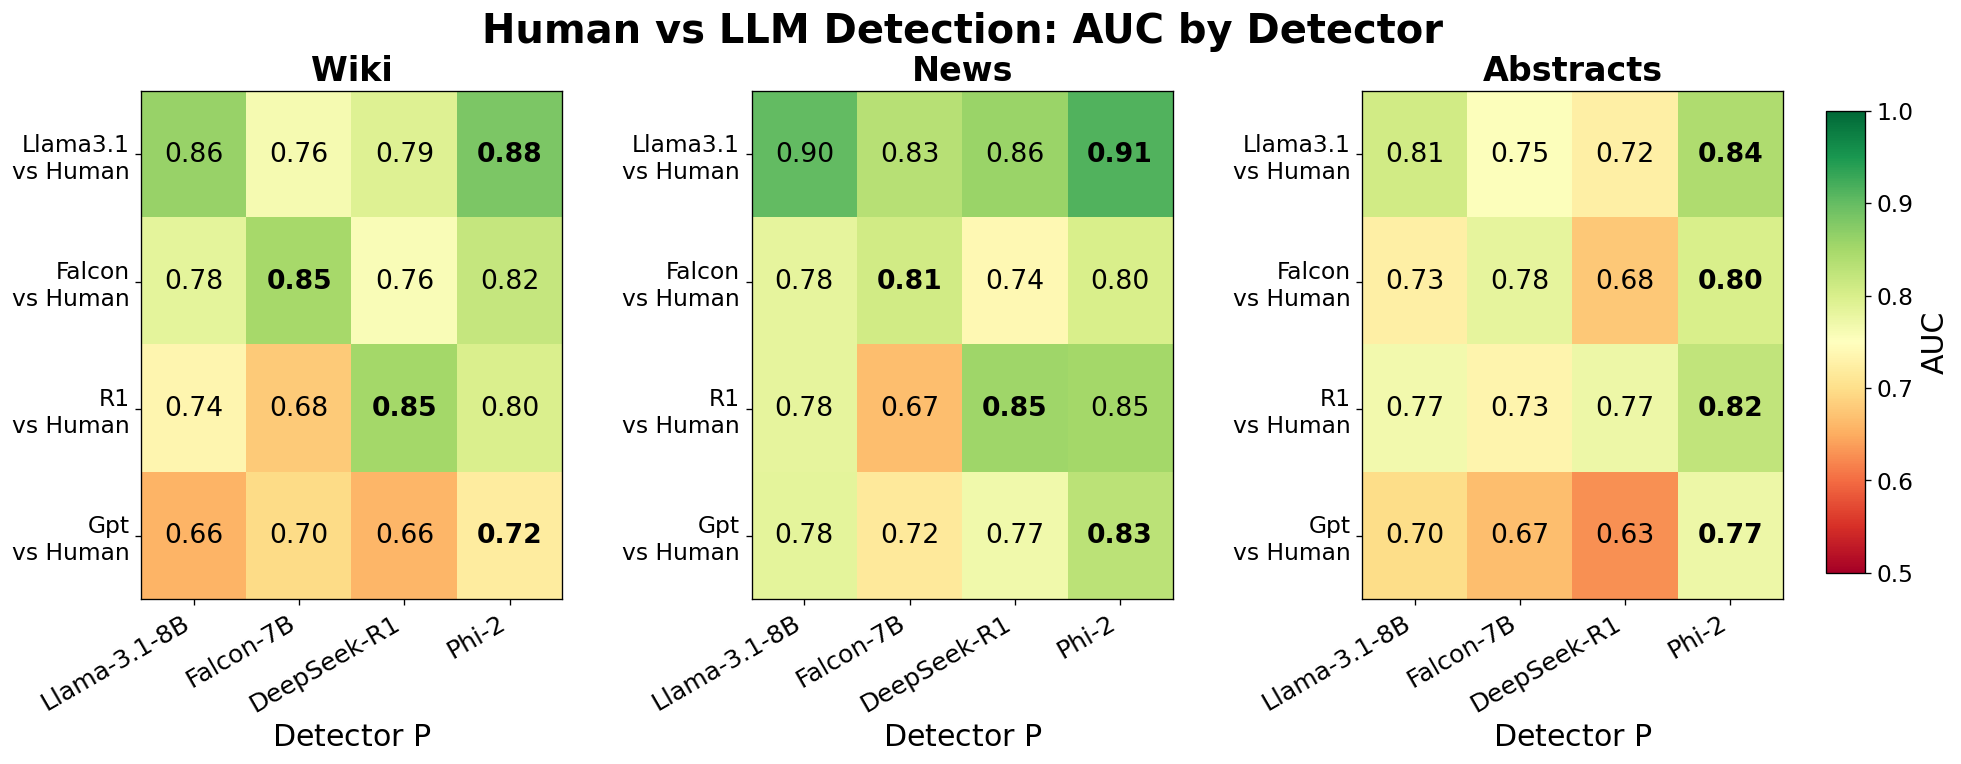

In [4]:
# ---- Computation (verbatim from isit_paper_figures.ipynb) ----
def compute_auc_matrix(dataset_paths, dataset_name, human_pairs_only=True):
    """Compute AUC matrix: rows = author pairs, columns = detectors."""
    results = []
    for det_idx, lm_paths in enumerate(dataset_paths):
        detector = DETECTOR_NAMES[det_idx]
        for i, auth1_path in enumerate(lm_paths):
            for j, auth2_path in enumerate(lm_paths):
                if i >= j:
                    continue
                _, auth1_name, _, _ = extract_info_from_path(auth1_path)
                _, auth2_name, _, _ = extract_info_from_path(auth2_path)
                auth1_short = auth1_name.split()[0]
                auth2_short = auth2_name.split()[0]
                if human_pairs_only:
                    if 'Human' not in auth1_short and 'Human' not in auth2_short:
                        continue
                auth1_df = pd.read_csv(auth1_path)
                auth2_df = pd.read_csv(auth2_path)
                mask1 = (auth1_df['length'] >= MIN_LENGTH) & (auth1_df['length'] <= MAX_LENGTH)
                mask2 = (auth2_df['length'] >= MIN_LENGTH) & (auth2_df['length'] <= MAX_LENGTH)
                subset1 = auth1_df.loc[mask1, 'response'].dropna()
                subset2 = auth2_df.loc[mask2, 'response'].dropna()
                if len(subset1) < 30 or len(subset2) < 30:
                    continue
                y_true = np.concatenate([np.zeros(len(subset1)), np.ones(len(subset2))])
                y_score = np.concatenate([subset1.values, subset2.values])
                auc = roc_auc_score(y_true, y_score)
                if auc < 0.5:
                    auc = 1 - auc
                detector_to_author = {'Llama-3.1-8B': 'Llama3.1', 'Falcon-7B': 'Falcon', 'DeepSeek-R1': 'R1'}
                det_author = detector_to_author.get(detector, None)
                is_self = det_author in [auth1_short, auth2_short]
                llm_author = auth1_short if auth2_short == 'Human' else auth2_short
                results.append({
                    'dataset': dataset_name, 'pair': llm_author, 'llm_author': llm_author,
                    'detector': detector, 'auc': auc, 'is_self': is_self
                })
    return pd.DataFrame(results)

wiki_auc = compute_auc_matrix(wiki_paths, 'Wiki', human_pairs_only=True)
news_auc = compute_auc_matrix(news_paths, 'News', human_pairs_only=True)
abstracts_auc = compute_auc_matrix(abstracts_paths, 'Abstracts', human_pairs_only=True)

# ---- Presentation plot ----
COL_ORDER = ['Llama-3.1-8B', 'Falcon-7B', 'DeepSeek-R1', 'Phi-2']
ROW_ORDER = ['Llama3.1', 'Falcon', 'R1', 'Gpt']

def create_auc_heatmap(auc_df, dataset_name, ax):
    pivot = auc_df.pivot(index='pair', columns='detector', values='auc')
    ordered_cols = [c for c in COL_ORDER if c in pivot.columns]
    pivot = pivot[ordered_cols]
    ordered_rows = [r for r in ROW_ORDER if r in pivot.index]
    pivot = pivot.loc[ordered_rows]
    im = ax.imshow(pivot.values, cmap='RdYlGn', aspect='auto', vmin=0.5, vmax=1.0)
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=30, ha='right', fontsize=15)
    ax.set_yticks(range(len(pivot.index)))
    row_labels = [f'{r}\nvs Human' for r in pivot.index]
    ax.set_yticklabels(row_labels, fontsize=14)
    ax.set_xlabel(r'Detector $\mathrm{P}$', fontsize=18)
    ax.set_title(dataset_name, fontsize=20, fontweight='bold')
    best_per_row = pivot.idxmax(axis=1)
    for i, pair in enumerate(pivot.index):
        best_det = best_per_row[pair]
        for j, det in enumerate(pivot.columns):
            val = pivot.iloc[i, j]
            if not np.isnan(val):
                is_best = (det == best_det)
                ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                        fontsize=16, fontweight='bold' if is_best else 'normal', color='black')
    return im

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
im1 = create_auc_heatmap(wiki_auc, 'Wiki', axes[0])
im2 = create_auc_heatmap(news_auc, 'News', axes[1])
im3 = create_auc_heatmap(abstracts_auc, 'Abstracts', axes[2])
plt.subplots_adjust(left=0.12, right=0.88, wspace=0.45)
cbar_ax = fig.add_axes([0.90, 0.15, 0.018, 0.7])
cbar = fig.colorbar(im3, cax=cbar_ax)
cbar.set_label('AUC', fontsize=18)
cbar.ax.tick_params(labelsize=14)
plt.suptitle('Human vs LLM Detection: AUC by Detector', y=1.0)
save_slide('human_detection_heatmap')
plt.show()

## 3. Optimal detector toy example — slide 6 (Theorem 2)

The original `epsilon_ball_example.png` is not produced by any committed notebook,
so this cell **reconstructs** the toy example to match the published figure:
distributions over 5 symbols with $P^* = G_0 - \gamma\,(G_1 - G_0)$, $\gamma=1.6$,
which reproduces $D(G_0\|P^*) \approx 0.10$ bits and the exact bar heights.

P* = [0.38 0.17 0.28 0.07 0.1 ]  |  D(G0||P*) = 0.10 bits  |  sum P* = 1.000


saved ../isit2026/figures/presentation/epsilon_ball_example.pdf


saved ../isit2026/figures/presentation/epsilon_ball_example.png


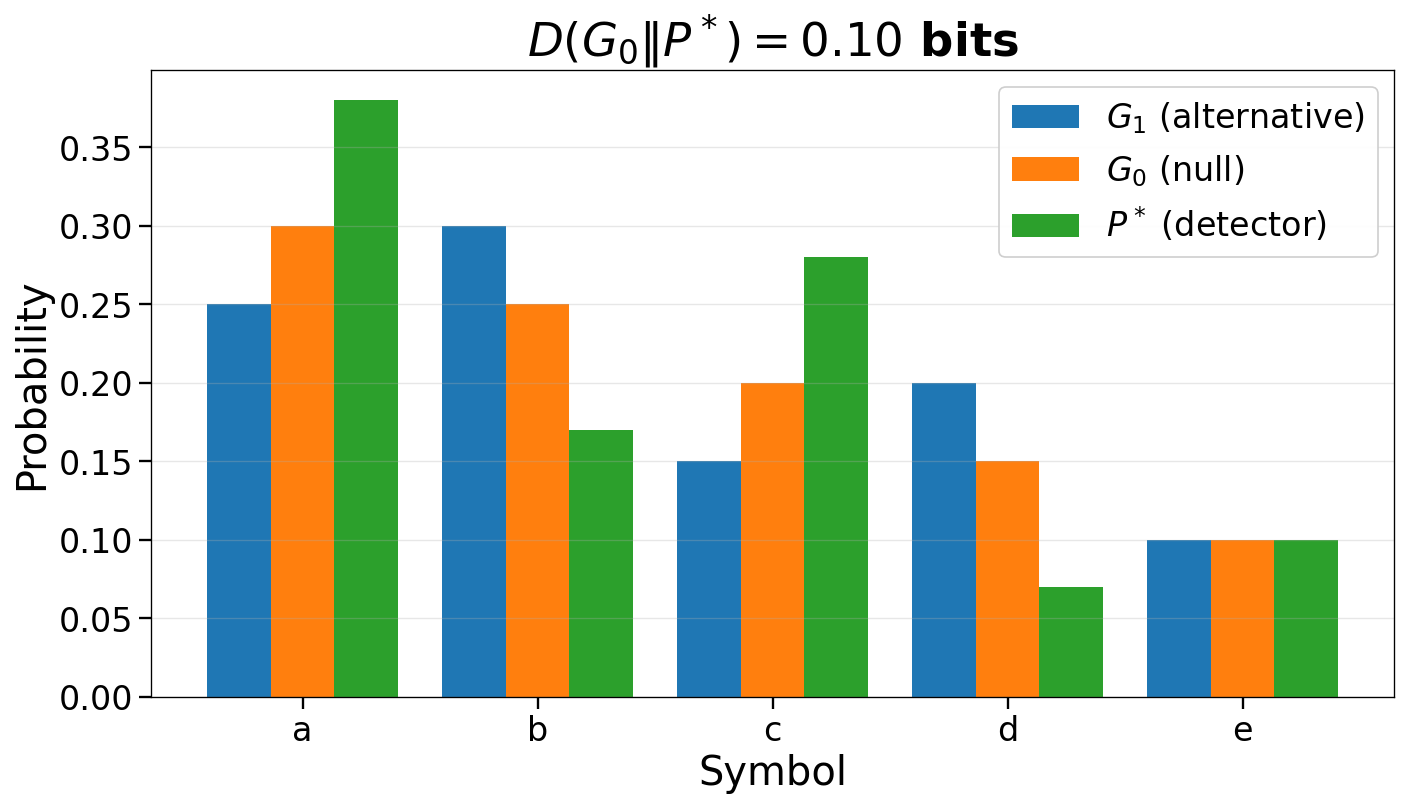

In [5]:
# Toy distributions over 5 symbols (reconstructed to match the published figure)
symbols = ['a', 'b', 'c', 'd', 'e']
G0 = np.array([0.30, 0.25, 0.20, 0.15, 0.10])  # null
G1 = np.array([0.25, 0.30, 0.15, 0.20, 0.10])  # alternative
gamma = 1.6
P_star = G0 - gamma * (G1 - G0)                 # optimal detector (Theorem 2)

# Relative entropy D(G0 || P*) in bits (matches the title in the original figure)
kl_bits = float(np.sum(G0 * np.log2(G0 / P_star)))
print(f"P* = {np.round(P_star, 3)}  |  D(G0||P*) = {kl_bits:.2f} bits  |  sum P* = {P_star.sum():.3f}")

x = np.arange(len(symbols))
width = 0.27
fig, ax = plt.subplots(figsize=(12, 7))
ax.bar(x - width, G1, width, label=r'$G_1$ (alternative)', color='C0')
ax.bar(x,         G0, width, label=r'$G_0$ (null)',        color='C1')
ax.bar(x + width, P_star, width, label=r'$P^*$ (detector)', color='C2')

ax.set_xlabel('Symbol', fontsize=27)
ax.set_ylabel('Probability', fontsize=27)
ax.set_title(rf'$D(G_0 \| P^*) = {kl_bits:.2f}$ bits', fontsize=28)
ax.set_xticks(x)
ax.set_xticklabels(symbols, fontsize=24)
ax.tick_params(width=1.4, length=7, labelsize=24)
ax.legend(framealpha=0.95, fontsize=20)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
save_slide('epsilon_ball_example')
plt.show()

## 4. AUC vs |Δ| by sentence length — backup B4

Computation verbatim from `delta_entropy_analysis.ipynb` (un-normalized Δ, fine
length bins). Shows why normalization is needed.

Total points: 1064


saved ../isit2026/figures/presentation/delta_auc_by_length.pdf


saved ../isit2026/figures/presentation/delta_auc_by_length.png


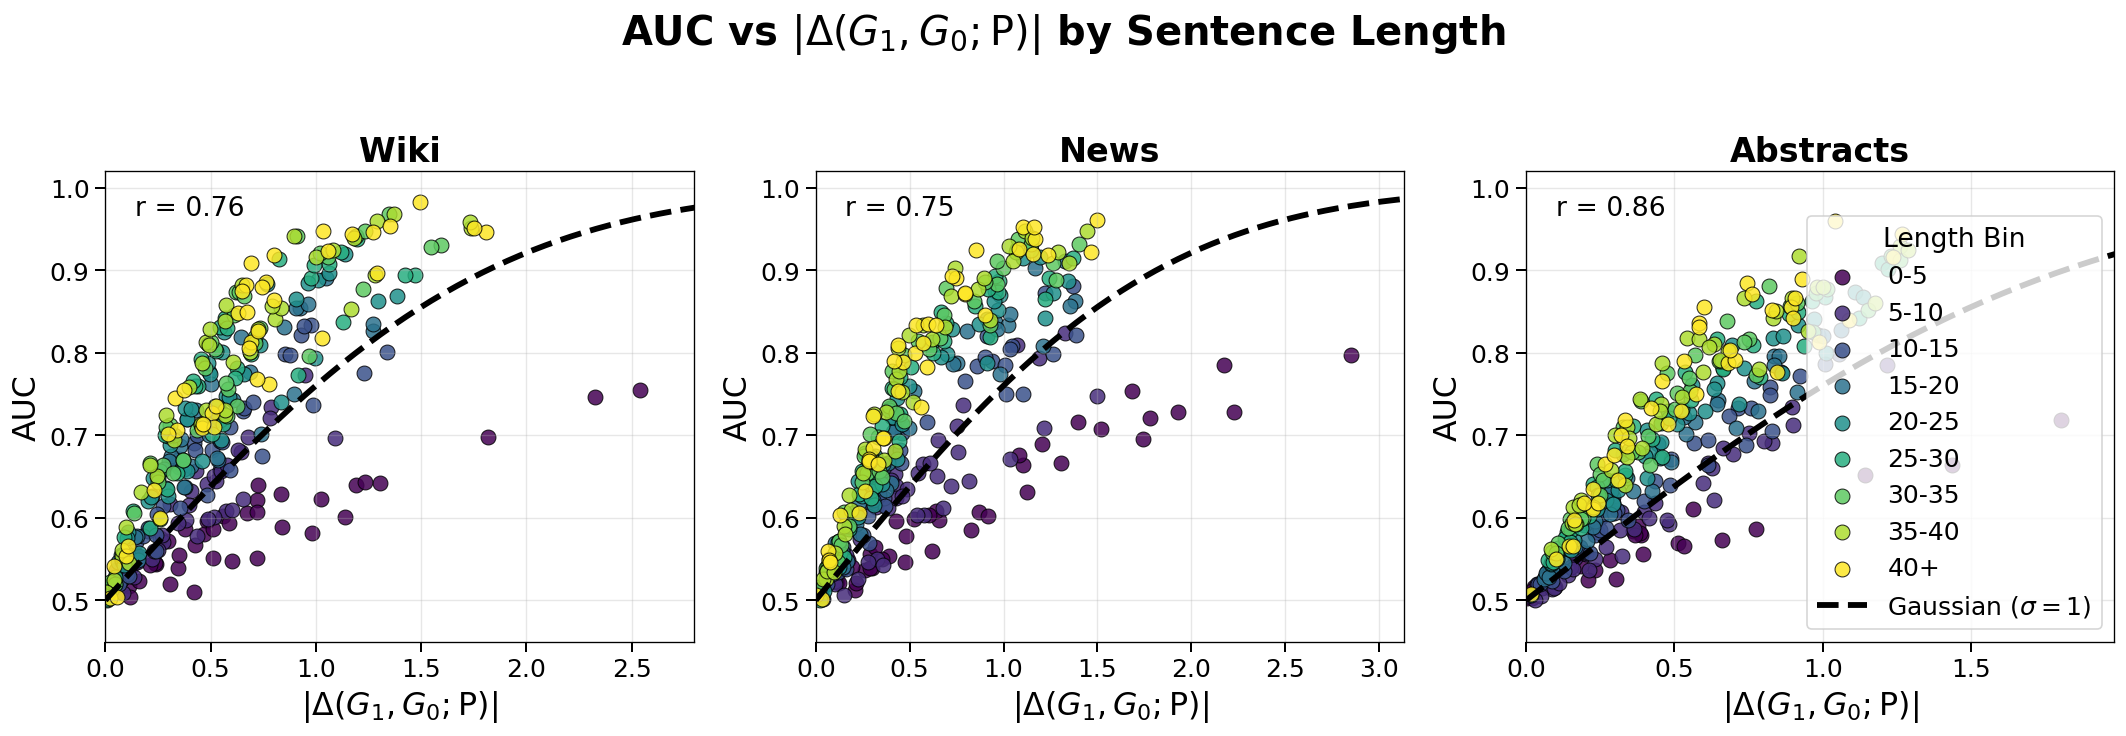

In [6]:
# ---- Computation (verbatim from delta_entropy_analysis.ipynb) ----
DL_LENGTH_BINS = [(0, 5), (5, 10), (10, 15), (15, 20), (20, 25), (25, 30), (30, 35), (35, 40), (40, float('inf'))]
DL_BIN_LABELS = ['0-5', '5-10', '10-15', '15-20', '20-25', '25-30', '30-35', '35-40', '40+']
DL_MIN_SAMPLES = 30

def gaussian_auc(delta, sigma=1.0):
    return norm.cdf(np.abs(delta) / (sigma * np.sqrt(2)))

def compute_auc_vs_delta_by_length(dataset_paths, dataset_name):
    results = []
    for lm_paths in dataset_paths:
        _, _, lm_name, _ = extract_info_from_path(lm_paths[0])
        for i, auth1_path in enumerate(lm_paths):
            for j, auth2_path in enumerate(lm_paths):
                if i >= j:
                    continue
                auth1_df = pd.read_csv(auth1_path)
                auth2_df = pd.read_csv(auth2_path)
                _, auth1_name, _, _ = extract_info_from_path(auth1_path)
                _, auth2_name, _, _ = extract_info_from_path(auth2_path)
                for bin_idx, (low, high) in enumerate(DL_LENGTH_BINS):
                    mask1 = (auth1_df['length'] >= low) & (auth1_df['length'] < high)
                    mask2 = (auth2_df['length'] >= low) & (auth2_df['length'] < high)
                    subset1 = auth1_df.loc[mask1, 'response'].dropna()
                    subset2 = auth2_df.loc[mask2, 'response'].dropna()
                    if len(subset1) < DL_MIN_SAMPLES or len(subset2) < DL_MIN_SAMPLES:
                        continue
                    mu_0, mu_1 = subset1.mean(), subset2.mean()
                    delta = mu_1 - mu_0
                    n0, n1 = len(subset1), len(subset2)
                    var0, var1 = subset1.var(), subset2.var()
                    pooled_var = ((n0 - 1) * var0 + (n1 - 1) * var1) / (n0 + n1 - 2)
                    pooled_std = np.sqrt(pooled_var)
                    y_true = np.concatenate([np.zeros(n0), np.ones(n1)])
                    y_score = np.concatenate([subset1.values, subset2.values])
                    auc = roc_auc_score(y_true, y_score)
                    if auc < 0.5:
                        auc = 1 - auc
                    results.append({
                        'delta': delta, 'abs_delta': abs(delta), 'auc': auc,
                        'pooled_std': pooled_std, 'length_bin': DL_BIN_LABELS[bin_idx],
                        'bin_idx': bin_idx, 'dataset': dataset_name, 'detector': lm_name,
                        'author1': auth1_name, 'author2': auth2_name, 'n0': n0, 'n1': n1
                    })
    return pd.DataFrame(results)

dl_wiki = compute_auc_vs_delta_by_length(wiki_paths, 'Wiki')
dl_news = compute_auc_vs_delta_by_length(news_paths, 'News')
dl_abstracts = compute_auc_vs_delta_by_length(abstracts_paths, 'Abstracts')
dl_all = pd.concat([dl_wiki, dl_news, dl_abstracts], ignore_index=True)
print(f"Total points: {len(dl_all)}")

# ---- Presentation plot ----
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
cmap = plt.cm.viridis
n_bins = len(DL_BIN_LABELS)
dl_bin_colors = {label: cmap(i / (n_bins - 1)) for i, label in enumerate(DL_BIN_LABELS)}
x_theory = np.linspace(0, 4, 200)

for ax, dataset in zip(axes, DATASET_NAMES):
    subset = dl_all[dl_all['dataset'] == dataset]
    for length_bin in DL_BIN_LABELS:
        bin_data = subset[subset['length_bin'] == length_bin]
        if len(bin_data) > 0:
            ax.scatter(bin_data['abs_delta'], bin_data['auc'],
                       c=[dl_bin_colors[length_bin]], label=length_bin,
                       alpha=0.85, s=80, edgecolors='black', linewidth=0.6)
    ax.plot(x_theory, gaussian_auc(x_theory, sigma=1.0), 'k--', linewidth=3.5,
            label=r'Gaussian ($\sigma=1$)')
    ax.set_xlabel(r'$|\Delta(G_1, G_0; \mathrm{P})|$')
    ax.set_ylabel('AUC')
    ax.set_title(dataset)
    ax.set_xlim(0, subset['abs_delta'].max() * 1.1)
    ax.set_ylim(0.45, 1.02)
    ax.tick_params(width=1.2, length=6)
    ax.grid(True, alpha=0.3)
    corr, _ = pearsonr(subset['abs_delta'], subset['auc'])
    ax.text(0.05, 0.95, f'r = {corr:.2f}', transform=ax.transAxes, va='top', fontsize=16)

handles, labels = axes[-1].get_legend_handles_labels()
theory_h = [h for h, l in zip(handles, labels) if 'Gaussian' in l]
theory_l = [l for l in labels if 'Gaussian' in l]
bin_h = [h for h, l in zip(handles, labels) if 'Gaussian' not in l]
bin_l = [l for l in labels if 'Gaussian' not in l]
axes[-1].legend(bin_h + theory_h, bin_l + theory_l, loc='lower right', title='Length Bin')
plt.suptitle(r'AUC vs $|\Delta(G_1, G_0; \mathrm{P})|$ by Sentence Length', y=1.03)
plt.tight_layout()
save_slide('delta_auc_by_length')
plt.show()

## 5. Variance ratio by sentence length — backup B5

Computation verbatim from `variance_independence_check.ipynb` (the line-plot
version used in the deck).

saved ../isit2026/figures/presentation/variance_ratio_by_length.pdf


saved ../isit2026/figures/presentation/variance_ratio_by_length.png


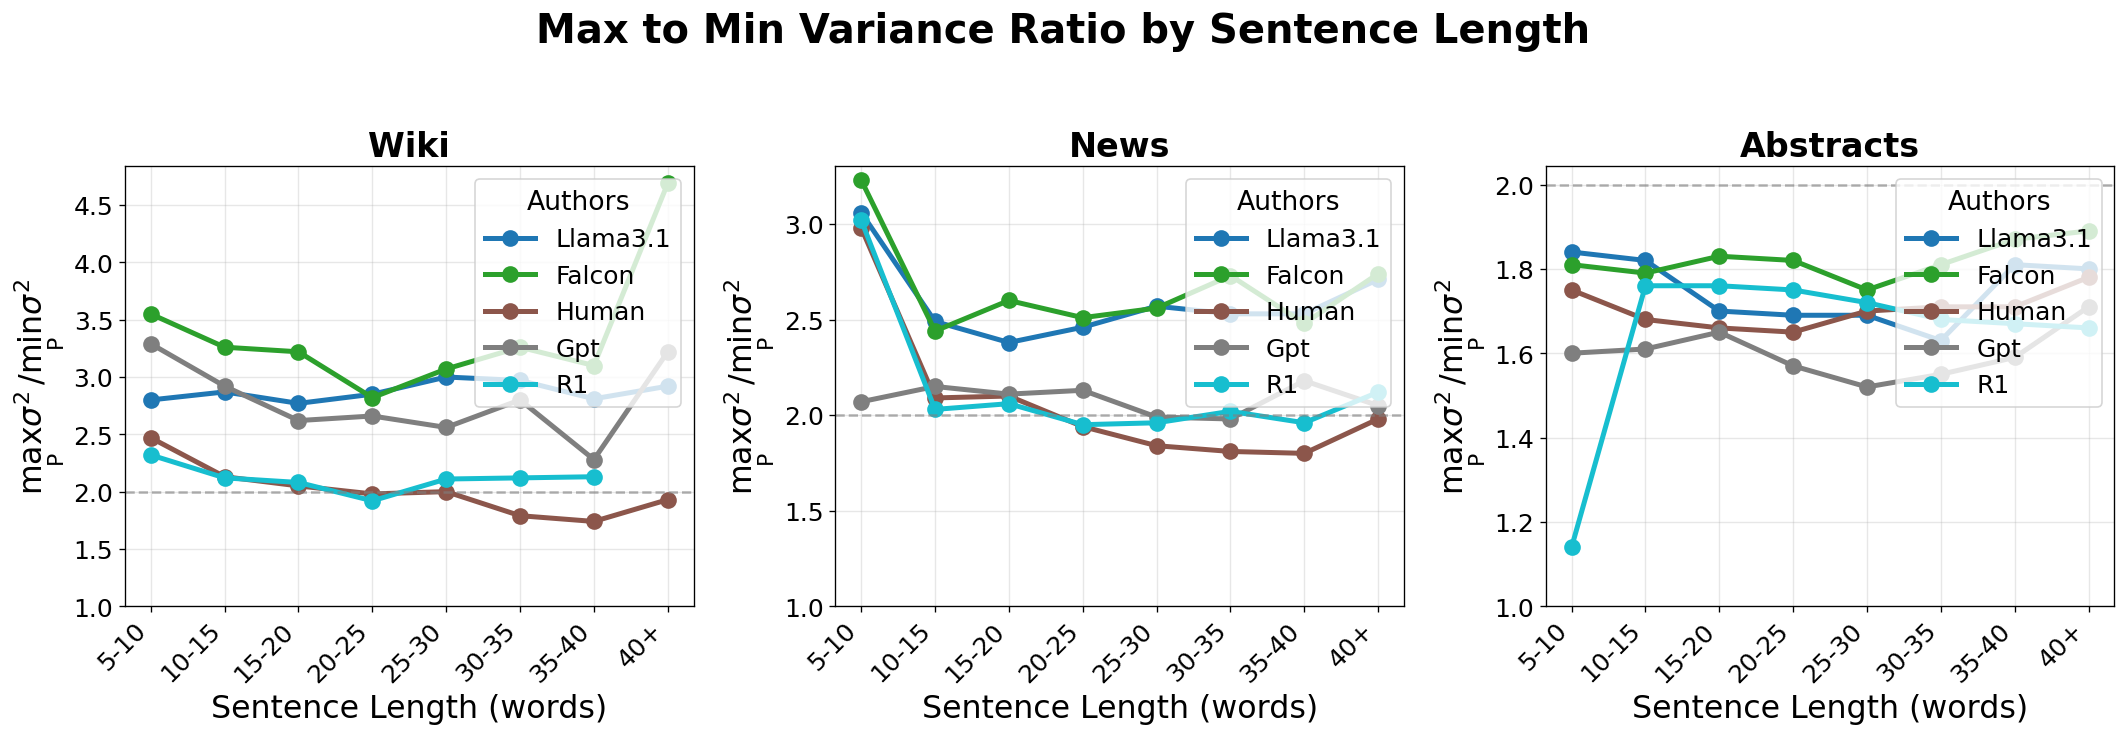

In [7]:
# ---- Computation (verbatim from variance_independence_check.ipynb) ----
VAR_MIN_SAMPLES = 60

def analyze_variance_by_author_length(dataset_paths, dataset_name):
    bins = [(0, 5), (5, 10), (10, 15), (15, 20), (20, 25), (25, 30), (30, 35), (35, 40), (40, float('inf'))]
    bin_labels = ['0-5', '5-10', '10-15', '15-20', '20-25', '25-30', '30-35', '35-40', '40+']
    detector_names = []
    author_names = []
    for lm_paths in dataset_paths:
        _, _, lm_name, _ = extract_info_from_path(lm_paths[0])
        detector_names.append(lm_name.replace(' ', '')[:8])
    for path in dataset_paths[0]:
        _, author, _, _ = extract_info_from_path(path)
        author_names.append(author.split()[0])
    detector_data = {}
    for det_idx, lm_paths in enumerate(dataset_paths):
        det_name = detector_names[det_idx]
        detector_data[det_name] = {}
        for auth_idx, path in enumerate(lm_paths):
            detector_data[det_name][author_names[auth_idx]] = pd.read_csv(path)[['length', 'response']]
    results = []
    for auth_name in author_names:
        for bin_idx, (low, high) in enumerate(bins):
            row = {'Author': auth_name, 'Length': bin_labels[bin_idx]}
            variances = []
            n_samples = None
            for det_name in detector_names:
                df = detector_data[det_name][auth_name]
                subset = df[(df['length'] >= low) & (df['length'] < high)]['response'].dropna()
                if n_samples is None:
                    n_samples = len(subset)
                if len(subset) >= VAR_MIN_SAMPLES:
                    var_val = subset.var()
                    row[f'Var({det_name})'] = round(var_val, 4)
                    variances.append(var_val)
                else:
                    row[f'Var({det_name})'] = np.nan
            row['N'] = n_samples
            if len(variances) >= 2:
                variances = np.array(variances)
                row['Ratio'] = round(variances.max() / variances.min(), 2)
            else:
                row['Ratio'] = np.nan
            results.append(row)
    return pd.DataFrame(results), detector_names, author_names

def plot_ratio_line_by_author(results_df, dataset_name, ax, skip_first_bin=True):
    authors = results_df['Author'].unique()
    lengths = results_df['Length'].unique()
    if skip_first_bin:
        lengths = lengths[1:]
    colors = plt.cm.tab10(np.linspace(0, 1, len(authors)))
    for i, author in enumerate(authors):
        author_data = results_df[results_df['Author'] == author]
        author_data = author_data[author_data['Length'].isin(lengths)]
        ratios = author_data['Ratio'].values
        ax.plot(range(len(lengths)), ratios, marker='o', label=author,
                color=colors[i], linewidth=3, markersize=9)
    ax.axhline(y=2, color='gray', linestyle='--', alpha=0.6, linewidth=1.5)
    ax.set_xticks(range(len(lengths)))
    ax.set_xticklabels(lengths, rotation=45, ha='right')
    ax.set_xlabel('Sentence Length (words)')
    ax.set_ylabel(r'$\max_{\mathrm{P}} \sigma^2 / \min_{\mathrm{P}} \sigma^2$')
    ax.set_title(dataset_name)
    ax.legend(loc='upper right', title='Authors')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(1, None)

var_wiki, _, _ = analyze_variance_by_author_length(wiki_paths, 'Wiki')
var_news, _, _ = analyze_variance_by_author_length(news_paths, 'News')
var_abstracts, _, _ = analyze_variance_by_author_length(abstracts_paths, 'Abstracts')

# ---- Presentation plot ----
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
plot_ratio_line_by_author(var_wiki, 'Wiki', axes[0])
plot_ratio_line_by_author(var_news, 'News', axes[1])
plot_ratio_line_by_author(var_abstracts, 'Abstracts', axes[2])
plt.suptitle('Max to Min Variance Ratio by Sentence Length', y=1.03)
plt.tight_layout()
save_slide('variance_ratio_by_length')
plt.show()

## 6. Unified Normalized AUC vs |Δ|/σ — all domains pooled (single panel)

All ~720 points from the three domains on one axis against the single Gaussian
curve. Reuses `all_results` / `bin_colors` / `x_theory` from section 1.

saved ../isit2026/figures/presentation/auc_vs_delta_normalized_unified.pdf
saved ../isit2026/figures/presentation/auc_vs_delta_normalized_unified.png


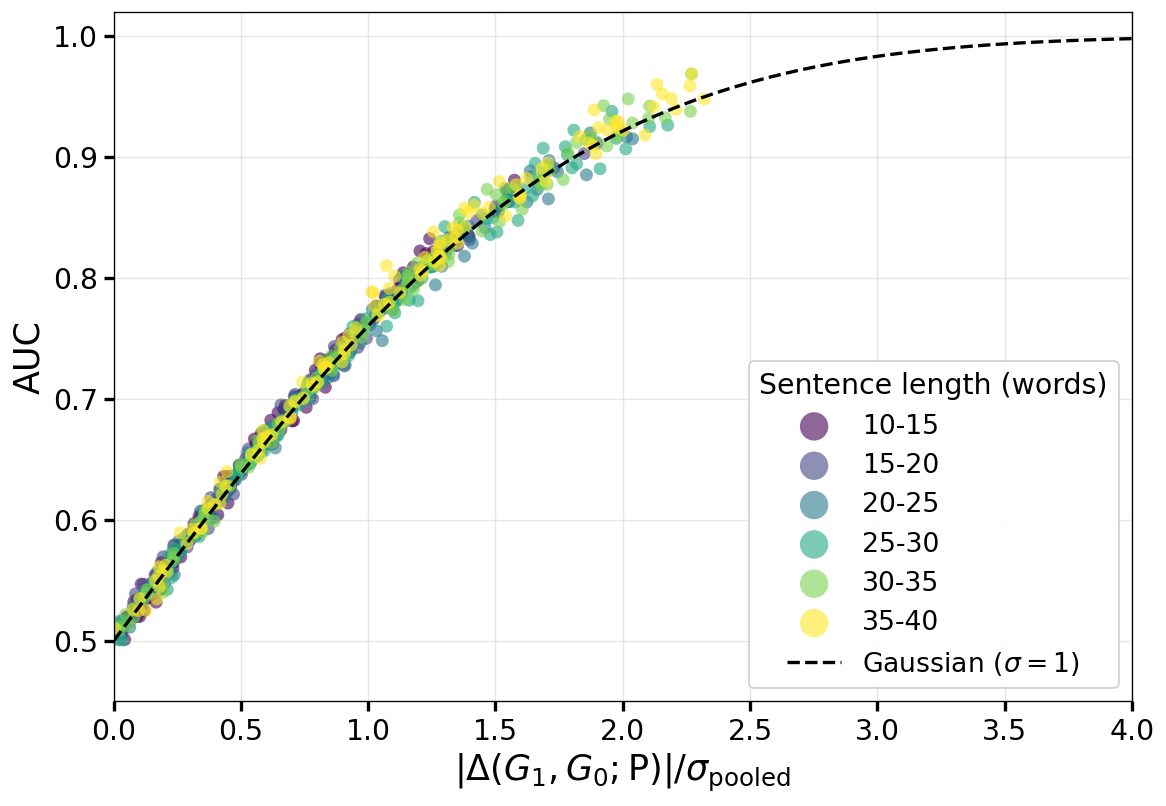

In [8]:
# Single-panel version: every comparison from all 3 domains, pooled.
# Many points -> small markers, light alpha, no edge; legend markers enlarged.
fig, ax = plt.subplots(figsize=(10, 7))

for length_bin in BIN_LABELS:
    bin_data = all_results[all_results['length_bin'] == length_bin]
    if len(bin_data) > 0:
        ax.scatter(bin_data['delta_normalized'], bin_data['auc'],
                   c=[bin_colors[length_bin]], label=length_bin,
                   alpha=0.6, s=60, edgecolors='none')

ax.plot(x_theory, y_theory, 'k--', linewidth=2, label=r'Gaussian ($\sigma=1$)')

ax.set_xlabel(r'$|\Delta(G_1, G_0; \mathrm{P})| / \sigma_{\mathrm{pooled}}$', fontsize=21)
ax.set_ylabel('AUC', fontsize=21)
# title intentionally omitted: the slide frame title + axis label already convey it
ax.set_xlim(0, 4)
ax.set_ylim(0.45, 1.02)
ax.tick_params(width=2, length=6, labelsize=17)
ax.grid(True, alpha=0.3)
# markerscale enlarges the tiny scatter dots in the legend so they stay readable
ax.legend(loc='lower right', title='Sentence length (words)', framealpha=0.95,
          markerscale=2.2, scatterpoints=1, fontsize=16, title_fontsize=17)

plt.tight_layout()
save_slide('auc_vs_delta_normalized_unified')
plt.show()

## 7. Averaged human-detection heatmap — mean AUC across the 3 domains

Single heatmap where each cell is the mean AUC over Wiki/News/Abstracts
(±std annotated). Best detector per row is highlighted in bold. Reuses
`wiki_auc` / `news_auc` / `abstracts_auc` / `COL_ORDER` / `ROW_ORDER` from section 2.

saved ../isit2026/figures/presentation/human_detection_heatmap_avg.pdf
saved ../isit2026/figures/presentation/human_detection_heatmap_avg.png


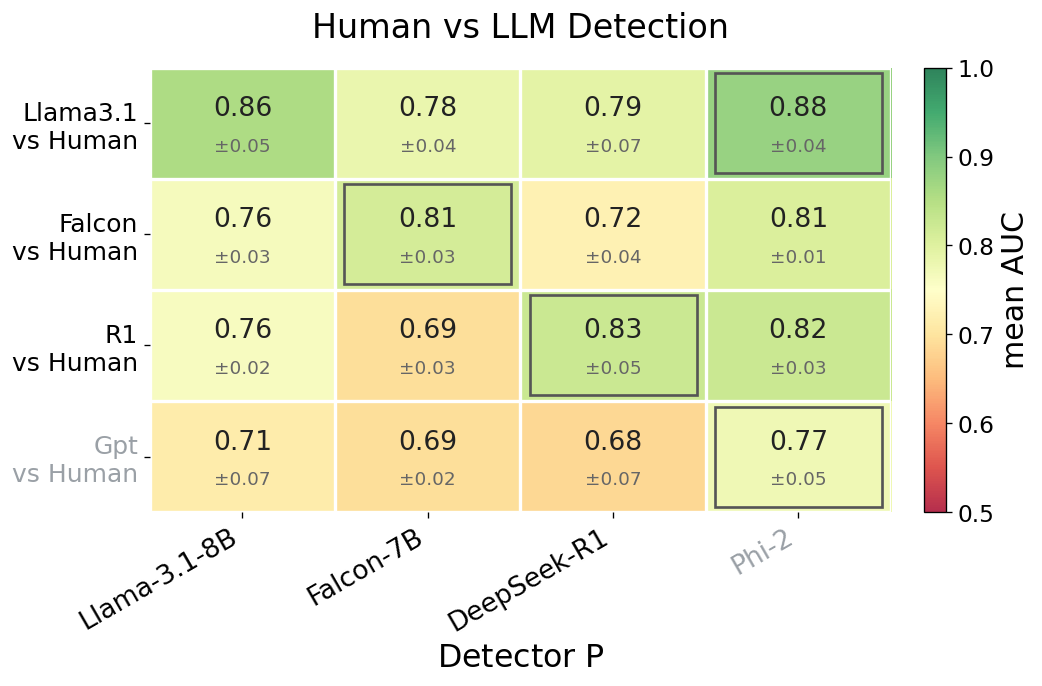

In [9]:
# Pool the three per-domain AUC tables and average each (pair, detector) cell.
combined_auc = pd.concat([wiki_auc, news_auc, abstracts_auc], ignore_index=True)
agg = combined_auc.groupby(['pair', 'detector'])['auc'].agg(['mean', 'std', 'count']).reset_index()

mean_p = agg.pivot(index='pair', columns='detector', values='mean')
std_p = agg.pivot(index='pair', columns='detector', values='std')

# Apply the same row/column ordering as the per-domain heatmap
cols = [c for c in COL_ORDER if c in mean_p.columns]
rows = [r for r in ROW_ORDER if r in mean_p.index]
mean_p = mean_p.loc[rows, cols]
std_p = std_p.loc[rows, cols]

fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(mean_p.values, cmap='RdYlGn', aspect='auto', vmin=0.5, vmax=1.0, alpha=0.82)

ax.set_xticks(range(len(mean_p.columns)))
ax.set_xticklabels(mean_p.columns, rotation=30, ha='right', fontsize=16)
ax.set_yticks(range(len(mean_p.index)))
ax.set_yticklabels([f'{r}\nvs Human' for r in mean_p.index], fontsize=15)
ax.set_xlabel(r'Detector $\mathrm{P}$', fontsize=19)
ax.set_title('Human vs LLM Detection', pad=18, fontweight='normal')

# Gray out detector/author labels that cannot do self-detection:
# Phi-2 has no matching author; GPT has no open-source detector.
GRAY = '#9aa0a6'
for lbl in ax.get_xticklabels():
    if lbl.get_text() == 'Phi-2':
        lbl.set_color(GRAY)
for lbl in ax.get_yticklabels():
    if lbl.get_text().startswith('Gpt'):
        lbl.set_color(GRAY)

# Highlight best detector per row (max mean) in bold
best_per_row = mean_p.idxmax(axis=1)
for i, pair in enumerate(mean_p.index):
    best_det = best_per_row[pair]
    for j, det in enumerate(mean_p.columns):
        m = mean_p.iloc[i, j]
        s = std_p.iloc[i, j]
        if not np.isnan(m):
            is_best = (det == best_det)
            # Mean (large, bold if best) with a smaller std underneath.
            ax.text(j, i - 0.13, f'{m:.2f}', ha='center', va='center',
                    fontsize=16, fontweight='normal', color='#222222')
            if not np.isnan(s):
                ax.text(j, i + 0.21, f'±{s:.2f}', ha='center', va='center',
                        fontsize=11, color='#666666')

# --- eye-candy: white cell separators, no spines, outline the best-in-row cell ---
from matplotlib.patches import Rectangle
ax.set_xticks(np.arange(-0.5, len(mean_p.columns), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(mean_p.index), 1), minor=True)
ax.grid(which='minor', color='white', linewidth=2)
ax.tick_params(which='minor', length=0)
for spine in ax.spines.values():
    spine.set_visible(False)
# Outline best-in-row cell. Inset slightly so the border has uniform thickness
# (a full-cell border gets clipped at the plot edges and looks thinner there).
for ii, pair in enumerate(mean_p.index):
    jj = list(mean_p.columns).index(best_per_row[pair])
    ax.add_patch(Rectangle((jj - 0.45, ii - 0.45), 0.9, 0.9, fill=False,
                           edgecolor='#555555', linewidth=1.6, zorder=5))

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('mean AUC', fontsize=18)
cbar.ax.tick_params(labelsize=14)

plt.tight_layout()
save_slide('human_detection_heatmap_avg')
plt.show()

## 8. Example log-loss histogram — slide 4 ("An Example")

Intro example: log-loss of wiki sentences from two authors (**Falcon** vs
**Human**) under a third model **P = Phi-2**. Rendered in the *default* pyplot
style (blue/orange) so it reads like raw notebook output, and saved
**transparent** so it blends onto the slide canvas instead of sitting on a
white box. The Falcon/Human pair under Phi-2 has nearly equal variance
(σ-ratio ≈ 1.2), consistent with the equal-variance assumption used later.

Falcon sd=0.63  Human sd=0.76  sigma-ratio=1.21
saved ../isit2026/figures/presentation/response_hist_example.pdf
saved ../isit2026/figures/presentation/response_hist_example.png


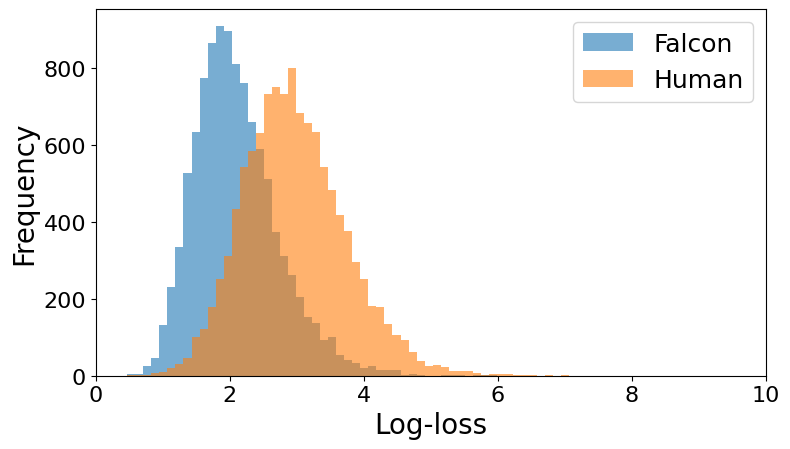

In [22]:
# Slide-4 example histogram: two authors under a third model P.
# Default pyplot look (blue/orange) so it reads like raw notebook output;
# save_slide() writes it transparent so it blends onto the slide canvas.
EX_DET = "phi-2"  # detector P
EX_FILES = {
    "Falcon": f"../Responses/wiki_Falcon_clean_none_{EX_DET}.csv",
    "Human":  f"../Responses/wiki_human_text_none_{EX_DET}.csv",
}

def _load_example(path):
    d = pd.read_csv(path)
    d = d[(d["length"] >= MIN_LENGTH) & (d["length"] <= MAX_LENGTH)]
    return d["response"].dropna().values

falcon = _load_example(EX_FILES["Falcon"])
human  = _load_example(EX_FILES["Human"])
ratio = max(falcon.std(ddof=1), human.std(ddof=1)) / min(falcon.std(ddof=1), human.std(ddof=1))
print(f"Falcon sd={falcon.std(ddof=1):.2f}  Human sd={human.std(ddof=1):.2f}  sigma-ratio={ratio:.2f}")

with plt.style.context("default"):  # stock matplotlib (overrides PRESENTATION_STYLE for this fig)
    fig, ax = plt.subplots(figsize=(8, 4.6))
    lo = min(falcon.min(), human.min()); hi = max(falcon.max(), human.max())
    bins = np.arange(lo, hi, 0.12)
    ax.hist(falcon, bins=bins, alpha=0.6, label="Falcon")  # C0 blue
    ax.hist(human,  bins=bins, alpha=0.6, label="Human")   # C1 orange
    ax.set_xlim(0, 10)
    ax.set_facecolor("none")   # transparent plot area so it blends on the slide canvas
    fig.patch.set_alpha(0)
    ax.set_xlabel(r"$L(X;P)/n$", fontsize=20)  # normalized log-loss (per-token)
    ax.set_ylabel("Frequency", fontsize=20)
    ax.tick_params(axis="both", labelsize=16)
    ax.legend(fontsize=18)
    fig.tight_layout()
    save_slide("response_hist_example_v2")  # transparent PDF + PNG into figures/presentation/
    plt.show()

---
## JMLR large-format empirical figures

This section prepares Figures 5--7 for the single-column JMLR page. The variance plot is rebuilt vertically so each domain uses the full text width. The normalized-AUC and heatmap computations are unchanged from the large-font presentation versions above; their vector outputs are copied to paper-local filenames for straightforward Overleaf transfer.

In [ ]:
from pathlib import Path
import shutil

PAPER_OUT = Path("../jmlr/figs")
PRESENTATION_OUT = Path(OUTDIR)
PAPER_OUT.mkdir(parents=True, exist_ok=True)

# Exact values printed by the executed sigma_df cell in isit_paper_figures.ipynb.
# Keeping them here avoids changing the empirical result while only changing layout.
sigma_records = [
    ("Wiki", "Llama-3.1-8B", "10--20", 0.705004),
    ("Wiki", "Llama-3.1-8B", "20--30", 0.603110),
    ("Wiki", "Llama-3.1-8B", "30--40", 0.670588),
    ("Wiki", "Falcon-7B", "10--20", 0.693623),
    ("Wiki", "Falcon-7B", "20--30", 0.592144),
    ("Wiki", "Falcon-7B", "30--40", 0.639828),
    ("Wiki", "Phi-2", "10--20", 0.708274),
    ("Wiki", "Phi-2", "20--30", 0.597073),
    ("Wiki", "Phi-2", "30--40", 0.657481),
    ("News", "Llama-3.1-8B", "10--20", 0.824802),
    ("News", "Llama-3.1-8B", "20--30", 0.635809),
    ("News", "Llama-3.1-8B", "30--40", 0.618381),
    ("News", "Falcon-7B", "10--20", 0.732230),
    ("News", "Falcon-7B", "20--30", 0.568886),
    ("News", "Falcon-7B", "30--40", 0.530860),
    ("News", "Phi-2", "10--20", 0.899687),
    ("News", "Phi-2", "20--30", 0.692551),
    ("News", "Phi-2", "30--40", 0.674526),
    ("Abstracts", "Llama-3.1-8B", "10--20", 0.795484),
    ("Abstracts", "Llama-3.1-8B", "20--30", 0.625318),
    ("Abstracts", "Llama-3.1-8B", "30--40", 0.606946),
    ("Abstracts", "Falcon-7B", "10--20", 0.806440),
    ("Abstracts", "Falcon-7B", "20--30", 0.628742),
    ("Abstracts", "Falcon-7B", "30--40", 0.603800),
    ("Abstracts", "Phi-2", "10--20", 0.892994),
    ("Abstracts", "Phi-2", "20--30", 0.710282),
    ("Abstracts", "Phi-2", "30--40", 0.687373),
]
sigma_jmlr = pd.DataFrame(sigma_records, columns=["dataset", "detector", "length_bin", "sigma"])

jmlr_style = {
    "font.size": 12,
    "axes.titlesize": 15,
    "axes.titleweight": "bold",
    "axes.labelsize": 13,
    "xtick.labelsize": 12,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "legend.title_fontsize": 11,
    "figure.titlesize": 17,
    "figure.titleweight": "bold",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
}

detectors = ["Llama-3.1-8B", "Falcon-7B", "Phi-2"]
length_bins = ["10--20", "20--30", "30--40"]
colors = ["#3498db", "#2ecc71", "#e74c3c"]
x = np.arange(len(detectors))
width = 0.23

with plt.rc_context(jmlr_style):
    fig, axes = plt.subplots(3, 1, figsize=(7.2, 10.0), sharey=True, constrained_layout=True)
    for ax, dataset in zip(axes, ["Wiki", "News", "Abstracts"]):
        subset = sigma_jmlr[sigma_jmlr["dataset"] == dataset]
        for index, (length_bin, color) in enumerate(zip(length_bins, colors)):
            values = [
                subset[(subset["detector"] == detector) & (subset["length_bin"] == length_bin)]["sigma"].iloc[0]
                for detector in detectors
            ]
            bars = ax.bar(x + (index - 1) * width, values, width, label=length_bin, color=color, alpha=0.88)
            ax.bar_label(bars, labels=[f"{value:.2f}" for value in values], padding=3, fontsize=10)
        ax.set_title(dataset)
        ax.set_ylabel(r"$\sigma(L(X;\mathrm{P}))$")
        ax.set_xticks(x, detectors)
        ax.set_ylim(0, 1.02)
        ax.grid(axis="y", alpha=0.25)
    axes[-1].set_xlabel(r"Detector model $\mathrm{P}$")
    axes[0].legend(title="Sentence length (words)", ncols=3, loc="upper center")
    fig.suptitle("Standard deviation of normalized log-loss by detector")
    for extension in ("pdf", "png"):
        fig.savefig(PAPER_OUT / f"sigma_vs_detector_jmlr.{extension}", dpi=300, facecolor="white")
    plt.show()

# These plots were already regenerated above with the same statistics and much
# larger typography than the original paper figures. Preserve their vector form.
for stem in ("auc_vs_delta_normalized", "human_detection_heatmap"):
    for extension in ("pdf", "png"):
        source = PRESENTATION_OUT / f"{stem}.{extension}"
        destination = PAPER_OUT / f"{stem}_jmlr.{extension}"
        shutil.copy2(source, destination)
        print(f"saved {destination}")

In [ ]:
from PIL import Image


def _trim_transparent(image, padding=24):
    """Trim transparent margins while retaining a small border."""
    bbox = image.getchannel("A").getbbox()
    if bbox is None:
        return image
    left, top, right, bottom = bbox
    left = max(0, left - padding)
    top = max(0, top - padding)
    right = min(image.width, right + padding)
    bottom = min(image.height, bottom + padding)
    return image.crop((left, top, right, bottom))


def make_two_row_jmlr_figure(stem, top_crop, boundaries=None):
    """Enlarge three horizontal panels by arranging them as two above one."""
    source = Image.open(PRESENTATION_OUT / f"{stem}.png").convert("RGBA")
    if boundaries is None:
        boundaries = [0, source.width // 3, 2 * source.width // 3, source.width]
    panels = []
    for left, right in zip(boundaries[:-1], boundaries[1:]):
        panel = source.crop((left, top_crop, right, source.height))
        panels.append(_trim_transparent(panel))

    max_width = max(panel.width for panel in panels)
    max_height = max(panel.height for panel in panels)
    gap = 80
    canvas = Image.new("RGBA", (2 * max_width + gap, 2 * max_height + gap), "white")
    positions = [
        ((max_width - panels[0].width) // 2, (max_height - panels[0].height) // 2),
        (max_width + gap + (max_width - panels[1].width) // 2, (max_height - panels[1].height) // 2),
        ((canvas.width - panels[2].width) // 2, max_height + gap + (max_height - panels[2].height) // 2),
    ]
    for panel, position in zip(panels, positions):
        canvas.alpha_composite(panel, position)

    png_path = PAPER_OUT / f"{stem}_jmlr_large.png"
    pdf_path = PAPER_OUT / f"{stem}_jmlr_large.pdf"
    canvas.save(png_path, dpi=(300, 300))
    canvas.convert("RGB").save(pdf_path, resolution=300)
    print(f"saved {png_path}")
    print(f"saved {pdf_path}")


# Remove only the global title; retain each domain title, axes, labels, legends,
# annotations, and the heatmap colorbar. The heatmap uses measured transparent
# gaps because its long row labels extend beyond equal-width thirds.
make_two_row_jmlr_figure("auc_vs_delta_normalized", top_crop=300)
make_two_row_jmlr_figure(
    "human_detection_heatmap",
    top_crop=130,
    boundaries=[0, 1482, 3008, 4903],
)